# Data diagnostics
Inspect data to see if it is physical now

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/perturbed_flame_data1e6.csv")
print(df.shape)


(76709, 112)


Mass fraction sums: min=1.000000, max=1.000000
Any NaNs? False
Any negative Y? False
Any negative rho? False
T range: 500.1 K to 2500.0 K
rho range: 0.1299 to 0.6531 kg/m3
P range: 101325.0 to 101325.0 Pa


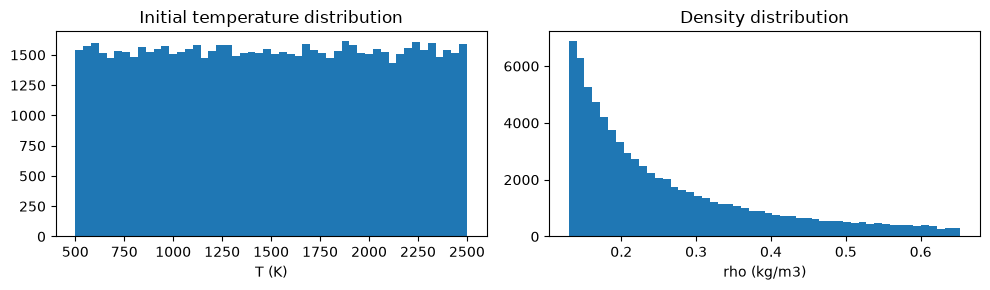

In [9]:
Y_cols = [c for c in df.columns if c.startswith("Y_")]
Ydot_cols = [c for c in df.columns if c.startswith("Ydot_")]

Y_sums = df[Y_cols].sum(axis=1)
print(f"Mass fraction sums: min={Y_sums.min():.6f}, max={Y_sums.max():.6f}")

print("Any NaNs?", df.isna().any().any())
print("Any negative Y?", (df[Y_cols] < 0).any().any())
print("Any negative rho?", (df["rho"] < 0).any())

print(f"T range: {df['T'].min():.1f} K to {df['T'].max():.1f} K")
print(f"rho range: {df['rho'].min():.4f} to {df['rho'].max():.4f} kg/m3")
print(f"P range: {df['P'].min():.1f} to {df['P'].max():.1f} Pa")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(df["T"], bins=50)
ax[0].set_xlabel("T (K)"); ax[0].set_title("Initial temperature distribution")
ax[1].hist(df["rho"], bins=50)
ax[1].set_xlabel("rho (kg/m3)"); ax[1].set_title("Density distribution")
plt.tight_layout()

Infeasible rows: 0 / 76709


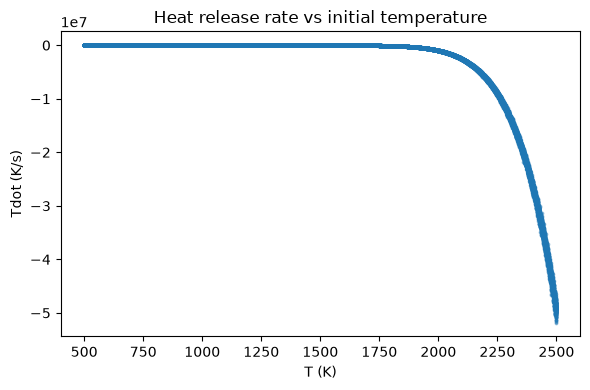

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["T"], df["Tdot"], s=3, alpha=0.4)
ax.set_xlabel("T (K)")
ax.set_ylabel("Tdot (K/s)")
ax.set_title("Heat release rate vs initial temperature")
plt.tight_layout()
mean_abs_ydot = df[Ydot_cols].abs().mean().sort_values(ascending=False)
mean_abs_ydot.head(15)
infeasible = df[(df["T"] < 200) | (df["T"] > 3500)]
print(f"Infeasible rows: {len(infeasible)} / {len(df)}")